In [82]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
warnings.filterwarnings('ignore')

In [83]:
sber = pd.read_csv('data/SBRF.txt')

In [84]:
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result


In [85]:
sber_15 = good_dataframe(sber, '5 min')
sber_15

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 10:30:00,SBRF,5 min,2301.0,2346.0,2265.0,2334.0,769
1,2009-01-11 10:35:00,SBRF,5 min,2334.0,2338.0,2320.0,2327.0,399
2,2009-01-11 10:40:00,SBRF,5 min,2322.0,2341.0,2322.0,2340.0,1825
3,2009-01-11 10:45:00,SBRF,5 min,2341.0,2355.0,2340.0,2350.0,2444
4,2009-01-11 10:50:00,SBRF,5 min,2350.0,2376.0,2349.0,2370.0,1614
...,...,...,...,...,...,...,...,...
675268,2025-06-30 23:25:00,SBRF,5 min,29865.0,29865.0,29847.0,29849.0,23
675269,2025-06-30 23:30:00,SBRF,5 min,29849.0,29853.0,29849.0,29849.0,51
675270,2025-06-30 23:35:00,SBRF,5 min,29849.0,29849.0,29846.0,29846.0,23
675271,2025-06-30 23:40:00,SBRF,5 min,29846.0,29851.0,29845.0,29845.0,92


# Смещение данных

In [86]:
def shift_features_2_candle(data):
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    for i in ['open', 'close', 'low', 'high', 'volume']:
        data_c[f'{i}_N-1'] = data_c[f'{i}_N-1'].astype('int32')
    return data_c

df = shift_features_2_candle(sber_15)
df

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,SBRF,5 min,2334.0,2301,2327.0,2334,2320.0,2265,2338.0,2346,399,769,2009-01-11 10:35:00,2009-01-11 10:30:00
2,SBRF,5 min,2322.0,2334,2340.0,2327,2322.0,2320,2341.0,2338,1825,399,2009-01-11 10:40:00,2009-01-11 10:35:00
3,SBRF,5 min,2341.0,2322,2350.0,2340,2340.0,2322,2355.0,2341,2444,1825,2009-01-11 10:45:00,2009-01-11 10:40:00
4,SBRF,5 min,2350.0,2341,2370.0,2350,2349.0,2340,2376.0,2355,1614,2444,2009-01-11 10:50:00,2009-01-11 10:45:00
5,SBRF,5 min,2371.0,2350,2361.0,2370,2355.0,2349,2380.0,2376,746,1614,2009-01-11 10:55:00,2009-01-11 10:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675268,SBRF,5 min,29865.0,29850,29849.0,29865,29847.0,29842,29865.0,29865,23,156,2025-06-30 23:25:00,2025-06-30 23:20:00
675269,SBRF,5 min,29849.0,29865,29849.0,29849,29849.0,29847,29853.0,29865,51,23,2025-06-30 23:30:00,2025-06-30 23:25:00
675270,SBRF,5 min,29849.0,29849,29846.0,29849,29846.0,29849,29849.0,29853,23,51,2025-06-30 23:35:00,2025-06-30 23:30:00
675271,SBRF,5 min,29846.0,29849,29845.0,29846,29845.0,29846,29851.0,29849,92,23,2025-06-30 23:40:00,2025-06-30 23:35:00


# Напишем функцию детекции свечного паттерна

In [87]:
def detection_bullish_engulfing_pattern(data):
    """
    Функция для детекции бычьего паттерна 'поглощение' (Bullish Engulfing) на ценовых данных."""

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data

In [88]:
def detection_bullish_harami_pattern(data):
    """
    Функция для детекции бычьего паттерна 'харами' (Bullish Harami) на ценовых данныx.
    Паттерн Харами состоит из большой медвежьей свечи, за которой следует маленькая бычья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи.
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие для бычьего харами
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (close_N_1 < open_N) & 
        (open_N_1 > close_N))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [89]:
def detection_break_in_the_clouds(data):
    """Первая свеча падающая, вторая растущая, открытие второй свечи ниже закрытия первой. перекрытия нет.
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'break_in_the_clouds'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N < close_N_1) & 
        (close_N < open_N_1))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [90]:
df_b = detection_bullish_engulfing_pattern(df)

Напишем функцию, которая считает прибыль или убыток при входе на цене открытия после завершения паттерна, держит позицию N следующих свечей, где N пробегает [1, 2, ..., 10, 15, 20, ..., 50] и выходит на закрытии последней свечи.

In [91]:
def filter_min_distance(data, column, N):
    data = data.copy()
    one_index = data[data[column] == 1].index
    
    distances = np.diff(one_index)
    mask = [True]
    
    current_distance = 0
    for dist in distances:
        current_distance += dist
        if current_distance >= N:
            mask.append(True)
            current_distance=0
        else:
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data
        

In [92]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics

def lst_trade_statistics_bull(data, commission=0.001):
   
   # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
   data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0

   # Проходимся циклом по периодам удержания позиции
   all_strategy = []
   for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
      
      data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
      strategy = [] # Список для результатов стратегии
      
      # Блок для определения цены входа и выхода
      exit_candidate = data_h['open_N'].shift(-N)
      is_entry = data_h['signal'] == 1
      entry_price = data_h['open_N'][is_entry]
      exit_price = exit_candidate[is_entry]
      
      # Считаем результат
      capital = 100_000
      profit_percent = (exit_price.values - entry_price.values) / entry_price.values # % доход за сделку
      profit = exit_price - entry_price
      
      # Считаем прибыль стратегии купи и держи:
      first_buy = data.loc[1, 'close_N']
      last_sell = data.loc[len(data) - 51, 'close_N']
      BH_strategy = ((last_sell - first_buy) / first_buy) * 100
      
      # Считаем результат стратегии 
      def calculate_relative_drawdown(lst):
        running_max = np.maximum.accumulate(lst)
        drawdown = (running_max - lst) 
        return np.max(drawdown)
     
      # Чистая прибыль
      absolut_profit_net = np.where(profit >= 0, profit * (1 - commission), profit * (1 + commission))
      percent_profit_net = np.where(profit_percent >= 0, profit_percent * (1 - commission), profit_percent * (1 + commission))
      total_return_net = (np.prod(1 + percent_profit_net) - 1) * 100 # общая прибыль в %
      capital_curve = capital * np.cumprod(1 + percent_profit_net)
      # Статистика
      
      # Названия
      strategy_name = data['strategy'][1]
      per = data['per'][1]
      ticker = data['ticker'][1]
      
      # Считаем R^2 линейной регрессии, построенной по графику дохода
      X = np.array(list(range(len(capital_curve)))).reshape(-1, 1)
      y = np.array(capital_curve)
      lin = LinearRegression()
      
      lin.fit(X, y)
      y_pred = lin.predict(X)
      r2 = metrics.r2_score(y, y_pred)
      all_strategy.append({'strategy' : strategy_name,
                           'ticker' : ticker,
                           'period' : per,
                           'N' : N,
                           'trades' : len(absolut_profit_net),
                           'win_rate' : np.round(np.mean(percent_profit_net > 0), 2), # Считаем по % доходу после уплаты комиссии
                           'profit_factor(%)' : np.round(np.sum(percent_profit_net[percent_profit_net > 0]) / np.abs(np.sum(percent_profit_net[percent_profit_net < 0])), 3),
                           'total_return' : np.round(total_return_net, 2), 'capital_curve' : capital_curve, 'profit' : profit,
                           'max_drawdown' : calculate_relative_drawdown(capital_curve), 'r2' : np.round(r2, 2),
                           'strategy_buy_and_hold' : BH_strategy})
   return pd.DataFrame(all_strategy)

result = lst_trade_statistics_bull(df_b)

result.head()

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return,capital_curve,profit,max_drawdown,r2,strategy_buy_and_hold
0,bullish_engulfing_pattern,SBRF,5 min,1,19601,0.46,1.023,21.46,"[100384.06663818881, 100213.31990801918, 10021...",3 9.0 107 -4.0 154 0.0 2...,25285.461978,0.47,1182.939407
1,bullish_engulfing_pattern,SBRF,5 min,2,19601,0.46,0.987,-24.50,"[101280.22212729605, 100892.61230522941, 10076...",3 30.0 107 -9.0 154 -3.0 2...,31521.060935,0.13,1182.939407
2,bullish_engulfing_pattern,SBRF,5 min,3,19040,0.47,0.975,-42.94,"[101066.85177274668, 100594.10448945453, 10020...",3 25.0 107 -11.0 154 -9.0 2...,53858.018110,0.24,1182.939407
3,bullish_engulfing_pattern,SBRF,5 min,4,18513,0.47,0.983,-37.08,"[100896.15548910722, 100681.63328935234, 10033...",3 21.0 107 -5.0 154 -8.0 2...,49710.538271,0.03,1182.939407
4,bullish_engulfing_pattern,SBRF,5 min,5,17992,0.48,0.994,-25.17,"[101152.19991456643, 100765.08004666909, 10063...",3 27.0 107 -9.0 154 -3.0 2...,56308.738675,0.03,1182.939407


Отбираем наилучшие стратегии для дальнейшего анализа с помощью моделей машинного обучения

In [93]:
l = []
for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
    sber_tm = good_dataframe(sber, i)
    l.append(sber_tm)

In [94]:
all_strategy = []
for detec in [detection_bullish_engulfing_pattern, detection_bullish_harami_pattern, detection_break_in_the_clouds]:
    for i in l:
        detection_data = detec(shift_features_2_candle(i))
        final_result = lst_trade_statistics_bull(detection_data)
        all_strategy.append(final_result)
        
    

In [95]:
combined_df = pd.concat(all_strategy, ignore_index=True)



In [96]:
combined_df = combined_df[combined_df['trades'] > 800]

In [97]:
combined_df['profit_factor_rank'] = combined_df['profit_factor(%)'].rank() # Больше лучше
combined_df['r2_rank'] = combined_df['r2'].rank() # Больше лучше
combined_df['max_drawdown_rank'] = combined_df['max_drawdown'].rank(ascending=False) # Меньше лучше
combined_df['best_model'] = combined_df['profit_factor_rank'] + combined_df['max_drawdown_rank'] + combined_df['r2_rank']
combined_df.sort_values('best_model', ascending=False, ignore_index=True, inplace=True)

In [98]:
combined_df

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return,capital_curve,profit,max_drawdown,r2,strategy_buy_and_hold,profit_factor_rank,r2_rank,max_drawdown_rank,best_model
0,break_in_the_clouds,SBRF,2h,3,1344,0.51,1.193,163.56,"[99094.31279620853, 100291.83560044334, 95227....",11 -21.0 18 27.0 24 -112.0 3...,49314.024996,0.89,1158.725406,234.0,246.0,220.0,700.0
1,bullish_engulfing_pattern,SBRF,30 min,2,4130,0.50,1.121,112.76,"[99871.66666666667, 99700.33583833191, 100127....",6 -3.0 14 -4.0 17 10.0 2...,31846.589770,0.88,1164.720920,198.5,244.5,240.0,683.0
2,bullish_engulfing_pattern,SBRF,2h,10,929,0.52,1.165,156.67,"[98499.57173447538, 88248.08025977382, 85151.3...",4 -35.0 41 -212.0 57 -59....,66745.202076,0.85,1158.725406,224.5,240.5,187.0,652.0
3,break_in_the_clouds,SBRF,2h,1,1411,0.52,1.149,53.42,"[99309.95260663507, 99754.4447332212, 96066.13...",11 -16.0 18 10.0 24 -82.0 38 ...,38933.928275,0.69,1158.725406,220.0,193.5,234.0,647.5
4,break_in_the_clouds,SBRF,2h,8,1086,0.52,1.121,94.62,"[96592.89099526066, 89188.74132829512, 82254.5...",11 -79.0 24 -170.0 38 -160.0 5...,67732.595397,0.78,1158.725406,198.5,223.5,183.0,605.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,bullish_engulfing_pattern,SBRF,15 min,9,6202,0.50,1.040,22.60,"[99229.01155327343, 98634.99388223219, 99383.1...",16 -18.0 56 -14.0 154 17....,185763.721353,0.06,1162.558238,94.0,43.0,58.0,195.0
242,bullish_engulfing_pattern,SBRF,15 min,40,3542,0.51,1.046,20.74,"[100645.3488372093, 98292.36803877447, 98771.5...",23 15.0 202 -49.0 242 10....,348668.010442,0.14,1162.558238,101.5,65.5,24.0,191.0
243,bullish_engulfing_pattern,SBRF,5 min,40,9211,0.50,1.035,69.53,"[99871.72148654421, 99616.90858966732, 98594.1...",3 -3.0 107 -6.0 154 -24....,152172.984778,0.00,1182.939407,88.0,7.5,85.0,180.5
244,break_in_the_clouds,SBRF,5 min,9,22142,0.51,1.032,94.93,"[99529.8462852263, 99487.26962875984, 99358.93...",23 -11.0 33 -1.0 57 -3....,162499.821603,0.01,1182.939407,85.0,19.0,74.0,178.0


In [99]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# for i in range(100):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#     # Первый график (ваш существующий)
#     ax1.set_title(f'{i} - Кумулятивная сумма сделок')
#     cumsume = np.cumsum(combined_df.loc[i, "profit"])
#     sns.lineplot(x=range(len(cumsume)), y=cumsume, ax=ax1)
#     ax1.set_xlabel('Номер сделки')
#     ax1.set_ylabel('Кумулятивная прибыль')
#     ax1.grid(True)

#     # Второй график (добавьте нужный вам)
#     ax2.set_title(f'{i} - Ваш второй график')
#     # Здесь добавьте данные для второго графика
#     # Например:
#     sns.lineplot(combined_df.loc[i, 'capital_curve'])
#     ax2.set_xlabel('Время/Сделки')
#     ax2.set_ylabel('Значение')
#     ax2.grid(True)

#     plt.tight_layout()
#     plt.show()
    

In [100]:
data = combined_df.loc[0]
data

strategy                                               break_in_the_clouds
ticker                                                                SBRF
period                                                                  2h
N                                                                        3
trades                                                                1344
win_rate                                                              0.51
profit_factor(%)                                                     1.193
total_return                                                        163.56
capital_curve            [99094.31279620853, 100291.83560044334, 95227....
profit                   11       -21.0
18        27.0
24      -112.0
3...
max_drawdown                                                  49314.024996
r2                                                                    0.89
strategy_buy_and_hold                                          1158.725406
profit_factor_rank       

In [101]:
y = data['profit']

In [102]:
sber_2h = good_dataframe(sber, '2h')
sber_clouds = detection_break_in_the_clouds(shift_features_2_candle(sber_2h))
sber_clouds = filter_min_distance(sber_clouds, 'signal', 3)
sber_clouds.loc[len(sber_clouds) - 51 : len(sber_clouds), ['pattern', 'signal']] = 0
for index in sber_clouds.index[1:]:
    if sber_clouds.loc[index, 'signal'] == 0 and sber_clouds.loc[index-1, 'pattern'] == 1:
        sber_clouds.loc[index-1, 'pattern'] = 0


In [103]:
print(sum(sber_clouds['signal']))
print(sum(sber_clouds['pattern']))
print(len(y))

1344
1344
1344


In [104]:
print(sum(sber_clouds['pattern']))

1344


In [105]:
sber_clouds['profit'] = 0
sber_clouds.loc[sber_clouds['pattern'] == 1, 'profit'] = np.array(y)


Мы создали готовый датафрейм, который можно использовать в дальнейшем

Теперь нам необходимо создать признаки для модели классификации

# Создадим много относительных признаков

In [106]:
# Признаки по дате и времени
def data_time_features(data):
    # Для текущей свечи
    data = data.copy()
    data['time_N'] = pd.to_datetime(data['time_N'])
    data['months_N'] = data['time_N'].dt.month
    data['days_N'] = data['time_N'].dt.day
    data['hours_N'] = data['time_N'].dt.hour
    
    return data

In [107]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    # Для текущей свечи
    data = data.copy()
    
    # Отношение тела свечи ко всей свече
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    data['ratio_body_to_all_candle_N'] = body_N / full_candle_N
    data['ratio_body_to_all_candle_N-1'] = body_N_1 / full_candle_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(1)
    
    # Отношение верхней тени к телу свечи
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    data['ratio_up_shadow_to_body_N'] = up_shadow_N / body_N
    data['ratio_up_shadow_to_body_N-1'] = up_shadow_N_1 / body_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    # Отношение нижней тени к телу свечи
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    data['ratio_low_shadow_to_body_N'] = low_shadow_N / body_N
    data['ratio_low_shadow_to_body_N-1'] = low_shadow_N_1 / body_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    # Отношение верхней тени к нижней тени
    data['ratio_up_shadow_to_low_shadow_N'] = up_shadow_N / low_shadow_N
    data['ratio_up_shadow_to_low_shadow_N-1'] = up_shadow_N_1 / low_shadow_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    return data
    
    

In [108]:
def data_one_candle_features_2(data):
    data = data.copy()
    
    def ATR(data, period=14):
        high_low = data['high_N'] - data['low_N']
        high_close_prev = np.abs(data['high_N'] - data['close_N'].shift(1))
        low_close_prev = np.abs(data['low_N'] - data['close_N'].shift(1))
    
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        ATR = TR.rolling(period).mean()
    
        return ATR
    
    atr = ATR(data)
    
    data = data.copy()
    valid_mask = ~atr.isna()
    data = data[valid_mask]
    atr = atr[valid_mask]
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    atr_safe = np.where(atr != 0, atr, 10e-8 )
    
    # Тело свечи / ATR
    data['body_ATR_N'] = body_N / atr_safe
    data['body_ATR_N-1'] = body_N_1 / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR_N'] = full_candle_N / atr_safe
    data['full_candle_ATR_N-1'] = full_candle_N_1 / atr_safe
    
    # Верхняя тень / ATR
    data['up_shadow_ATR_N'] = up_shadow_N / atr_safe
    data['up_shadow_ATR_N_1'] = up_shadow_N_1 / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR_N'] = low_shadow_N / atr_safe
    data['low_shadow_ATR_N_1'] = low_shadow_N_1 / atr_safe
    
    
    return data

In [109]:
def data_two_candles_features(data):
    data = data.copy()
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    
    # Отношение: тело свечи N / тело свечи N-1
    data['body_N / body_N-1'] = body_N / body_N_1
    
    # Отношение вся свеча N / вся свеча N-1
    data['full candle N / full_candle_N-1'] = full_candle_N / full_candle_N_1
    
    # Отношение: вехней тени N / верхней тени N-1
    data['up_shadow_N / up_shadow_N-1'] =  up_shadow_N / up_shadow_N_1
    
    # Отношение: нижней тени N / нижней тени N-1
    data['low_shadow_N / low_shadow_N-1'] =  low_shadow_N / low_shadow_N_1
     
    return data
    
    

In [110]:
pip install ta

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [111]:
def indicators(data):
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        # Расчитываем первые значения
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            rs = avg_gain / avg_loss
            rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI_N'] = rsi(data['close_N'], 14)
    
    # БЛОК SMA
    # Смотрим отклонение цены от скользящих средних
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200] 
    for i in sma_periods:
        sma_N = data['close_N'].rolling(i).mean()
        sma_N_1 = data['close_N-1'].rolling(i).mean()
        # Отклонение
        data[f'diff_SMA_{i}_N'] = (((data['close_N'] - sma_N) + 10e-8) * 100) / sma_N
        data[f'diff_SMA_{i}_N_1'] = (((data['close_N-1'] - sma_N_1) + 10e-8) *100) / sma_N_1
    
    # Объём
    def volume(data, column):
        data = data.copy()
        volume_ma = data[column].rolling(63).mean()
        volume_std = data[column].rolling(63).std()
        data[f'{column}_Z'] = (data[column] - volume_ma) / volume_std
        return data
    
    data = volume(data, 'volume_N')
    data = volume(data, 'volume_N-1')
    
    # Индикатор Стохастик
    data.ta.stoch(high='high_N', low='low_N', close='close_N',
           col_names=('STOCH_K_N', 'STOCH_D_N', 'STOCH_RAW_N'), append=True)

    data.ta.stoch(high='high_N-1', low='low_N-1', close='close_N-1',
           col_names=('STOCH_K_N-1', 'STOCH_D_N-1', 'STOCH_RAW_N-1'), append=True)
    
    data.dropna(inplace=True)
    return data



In [112]:
def indicators(data):
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        # Рассчитываем первые значения
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / avg_loss
                rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI_N'] = rsi(data['close_N'], 14)
    
    # БЛОК SMA
    # Смотрим отклонение цены от скользящих средних
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200] 
    for i in sma_periods:
        sma_N = data['close_N'].rolling(i).mean()
        sma_N_1 = data['close_N-1'].rolling(i).mean()
        # Отклонение
        data[f'diff_SMA_{i}_N'] = (((data['close_N'] - sma_N) + 1e-8) * 100) / sma_N
        data[f'diff_SMA_{i}_N_1'] = (((data['close_N-1'] - sma_N_1) + 1e-8) * 100) / sma_N_1
    
    # Объём
    def volume(data, column):
        data = data.copy()
        volume_ma = data[column].rolling(63).mean()
        volume_std = data[column].rolling(63).std()
        # Добавляем small epsilon чтобы избежать деления на 0
        data[f'{column}_Z'] = (data[column] - volume_ma) / (volume_std + 1e-8)
        return data
    
    data = volume(data, 'volume_N')
    data = volume(data, 'volume_N-1')
    
    # ИНДИКАТОР СТОХАСТИК
    def stochastic_oscillator(high, low, close, k_period=14, d_period=3):
        # Находим минимумы и максимумы за период k_period
        low_min = low.rolling(window=k_period).min()
        high_max = high.rolling(window=k_period).max()
        
        # Рассчитываем %K
        k = 100 * (close - low_min) / (high_max - low_min + 1e-8)
        
        d = k.rolling(window=d_period).mean()
        
        return k, d
    
    # Стохастик для свечи N
    stoch_k_N, stoch_d_N = stochastic_oscillator(
        data['high_N'], data['low_N'], data['close_N']
    )
    data['STOCH_K_N'] = stoch_k_N
    data['STOCH_D_N'] = stoch_d_N
    data['STOCH_RAW_N'] = stoch_k_N  # RAW обычно это %K
    
    # Стохастик для свечи N-1
    stoch_k_N1, stoch_d_N1 = stochastic_oscillator(
        data['high_N-1'], data['low_N-1'], data['close_N-1']
    )
    data['STOCH_K_N-1'] = stoch_k_N1
    data['STOCH_D_N-1'] = stoch_d_N1
    data['STOCH_RAW_N-1'] = stoch_k_N1
    
    data.dropna(inplace=True)
    return data

In [113]:
def create_lag_indicators(data):
    data = data.copy()
    periods = [1, 3, 5, 10, 15, 20]
    daily_change = data['close_N'].pct_change()
    for i in periods:
        data[f'Change_{i}_N'] = (data['close_N'] / data['close_N'].shift(i) - 1) * 100
        data[f'Change_{i}_N-1'] = (data['close_N-1'] / data['close_N-1'].shift(i) - 1) * 100
        data[f'up_days_{i}'] = (daily_change > 0).rolling(i).sum()
        data[f'down_days_{i}'] = (daily_change < 0).rolling(i).sum()
        data[f'up_down_ratio_{i}'] = np.where(data[f'down_days_{i}'] != 0, data[f'up_days_{i}'] / data[f'down_days_{i}'], 0 )
        
    # Посчитаем количество растущих и падающих свеч за эти периоды
    data.dropna(inplace=True)
    return data

In [114]:
df_full = data_time_features(sber_clouds)
df_full = data_one_candle_features_1(df_full)
df_full = data_one_candle_features_2(df_full)
df_full = indicators(df_full)
df_full = create_lag_indicators(df_full)
df_full

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,...,Change_15_N,Change_15_N-1,up_days_15,down_days_15,up_down_ratio_15,Change_20_N,Change_20_N-1,up_days_20,down_days_20,up_down_ratio_20
234,SBRF,2h,1468.0,1443,1456.0,1469,1447.0,1441,1475.0,1469,...,1.605024,3.160112,7.0,8.0,0.875000,2.319044,2.369338,10.0,10.0,1.000000
235,SBRF,2h,1463.0,1468,1467.0,1456,1457.0,1447,1474.0,1475,...,1.592798,1.605024,7.0,8.0,0.875000,3.309859,2.319044,11.0,9.0,1.222222
236,SBRF,2h,1467.0,1463,1463.0,1467,1460.0,1457,1472.0,1474,...,2.450980,1.592798,7.0,8.0,0.875000,2.379286,3.309859,10.0,10.0,1.000000
237,SBRF,2h,1466.0,1467,1433.0,1463,1430.0,1460,1473.0,1472,...,-1.916496,2.450980,6.0,9.0,0.666667,1.487252,2.379286,10.0,10.0,1.000000
238,SBRF,2h,1439.0,1466,1436.0,1433,1431.0,1430,1467.0,1473,...,-2.907370,-1.916496,6.0,9.0,0.666667,0.842697,1.487252,10.0,10.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29729,SBRF,2h,29813.0,29687,29838.0,29822,29787.0,29646,29860.0,29870,...,0.834713,0.835165,8.0,7.0,1.142857,0.484946,0.370221,12.0,8.0,1.500000
29730,SBRF,2h,29839.0,29813,29889.0,29838,29793.0,29787,29900.0,29860,...,1.082214,0.834713,9.0,6.0,1.500000,0.426719,0.484946,12.0,8.0,1.500000
29731,SBRF,2h,29889.0,29839,29859.0,29889,29815.0,29793,29898.0,29900,...,1.073049,1.082214,9.0,6.0,1.500000,1.052525,0.426719,12.0,8.0,1.500000
29732,SBRF,2h,29858.0,29889,29865.0,29859,29847.0,29815,29879.0,29898,...,1.182410,1.073049,10.0,5.0,2.000000,1.035218,1.052525,12.0,8.0,1.500000


In [115]:
def last_prepare(data):
    data = data.copy()
    data.drop(['open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N', 'low_N-1',
       'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N-1', 
       'signal', 'strategy', 'ticker', 'per'], axis=1, inplace=True)
    return data
df_ml = last_prepare(df_full)
df_ml.head()

,time_N,pattern,profit,months_N,days_N,hours_N,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,...,Change_15_N,Change_15_N-1,up_days_15,down_days_15,up_down_ratio_15,Change_20_N,Change_20_N-1,up_days_20,down_days_20,up_down_ratio_20
234,2009-02-26 16:00:00,0,0,2,26,16,0.428571,0.928571,0.583333,0.000000,...,1.605024,3.160112,7.0,8.0,0.875000,2.319044,2.369338,10.0,10.0,1.000000
235,2009-02-26 18:00:00,0,0,2,26,18,0.235294,0.428571,1.750000,0.583333,...,1.592798,1.605024,7.0,8.0,0.875000,3.309859,2.319044,11.0,9.0,1.222222
236,2009-02-26 20:00:00,0,0,2,26,20,0.333333,0.235294,1.250000,1.750000,...,2.450980,1.592798,7.0,8.0,0.875000,2.379286,3.309859,10.0,10.0,1.000000
237,2009-02-26 22:00:00,0,0,2,26,22,0.767442,0.333333,0.212121,1.250000,...,-1.916496,2.450980,6.0,9.0,0.666667,1.487252,2.379286,10.0,10.0,1.000000
238,2009-02-27 10:00:00,0,0,2,27,10,0.083333,0.767442,9.333333,0.212121,...,-2.907370,-1.916496,6.0,9.0,0.666667,0.842697,1.487252,10.0,10.0,1.000000


# Создаём целевую переменную

In [116]:
df_ml['target'] = np.where(df_ml['profit'] > 0, 1, 0)
df_ml_after = df_ml[df_ml['time_N'] >= pd.to_datetime('2023-01-01 00:00:00')]

In [117]:
df_ml = df_ml[df_ml['pattern'] == 1]

In [118]:
df_ml.drop(['profit', 'pattern'], axis=1, inplace=True)

In [119]:
# Разделяем данные
X = df_ml.drop('target', axis=1)
y = df_ml['target']

# Создаем маску по дате
date_mask = X['time_N'] < pd.to_datetime('2023-01-01 00:00:00')

# Разделяем и X и y
X_train = X[date_mask]
X_test = X[~date_mask]
y_train = y[date_mask] 
y_test = y[~date_mask]

X_train.drop('time_N', axis=1, inplace=True)
X_test.drop('time_N', axis=1, inplace=True)

Проверим данные на мультиколлинеарность

In [120]:
d = {}
for i in X_train.columns:
    for j in X_train.columns:
        if i == j:
            continue
        cor = X_train[i].corr(X_train[j])
        d[f'{i}_{j}'] = np.round(cor, 3)
        
dic = pd.DataFrame(list(d.items()), columns = ['features', 'corr'])

In [121]:
features_to_remove = [
    'down_days_1', 'down_days_3', 'down_days_5', 'down_days_10', 'down_days_15', 'down_days_20',
    'up_down_ratio_5', 'up_down_ratio_10', 'up_down_ratio_20',
    'Change_1_N-1', 'Change_3_N-1', 'Change_5_N-1',
    'diff_SMA_5_N_1', 'diff_SMA_10_N_1', 'diff_SMA_20_N_1',
    'Change_3_N', 'Change_10_N', 'Change_10_N-1', 'Change_15_N'
]
X_train.drop(features_to_remove, axis=1, inplace=True)
X_test.drop(features_to_remove, axis=1, inplace=True)

In [122]:
d1 = {}
for i in X_train.columns:
    cor = X_train[i].corr(y_train)
    d1[i] = np.round(cor, 3)
        
dic1 = pd.DataFrame(list(d1.items()), columns = ['features', 'corr'])

In [123]:
X_train

,months_N,days_N,hours_N,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,ratio_up_shadow_to_low_shadow_N,...,up_down_ratio_3,Change_5_N,up_days_5,up_days_10,Change_15_N-1,up_days_15,up_down_ratio_15,Change_20_N,Change_20_N-1,up_days_20
278,3,6,20,0.125000,0.454545,3.000000,0.000000,4.000000,1.200000,0.750000,...,2.0,1.211735,3.0,6.0,-2.579853,8.0,1.142857,3.861257,4.963600,12.0
355,3,24,20,0.044444,0.123596,10.000000,0.000000,11.500000,7.090909,0.869565,...,0.5,-5.637745,1.0,5.0,2.699173,7.0,0.875000,-0.631579,-1.831045,9.0
375,3,27,18,0.018519,0.272727,39.000000,0.500000,14.000000,2.166667,2.785714,...,0.0,-11.753067,0.0,3.0,-6.769103,6.0,0.666667,-5.508475,-4.832556,9.0
387,3,31,14,0.027778,0.291667,24.000000,1.142857,11.000000,1.285714,2.181818,...,0.5,2.651326,1.0,1.0,-16.081633,2.0,0.153846,-17.224687,-18.606492,4.0
411,4,3,20,0.047619,0.250000,8.000000,0.000000,12.000000,3.000000,0.666667,...,1.0,0.791557,2.0,5.0,12.739793,9.0,1.800000,8.420057,7.454290,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24783,12,23,10,0.384058,0.339181,0.698113,0.362069,0.905660,1.586207,0.770833,...,2.0,-0.035668,2.0,4.0,-0.838068,8.0,1.142857,0.128617,-0.299914,12.0
24788,12,23,20,0.187500,0.710843,3.555556,0.186441,0.777778,0.220339,4.571429,...,2.0,0.028545,3.0,5.0,0.343716,7.0,0.875000,-0.581602,-0.475852,11.0
24809,12,28,14,0.255102,0.397436,0.280000,0.677419,2.640000,0.838710,0.106061,...,0.5,-0.337055,3.0,5.0,-1.130417,8.0,1.142857,1.169007,1.084398,12.0
24812,12,28,20,0.078431,0.600000,8.500000,0.380952,3.250000,0.285714,2.615385,...,2.0,0.014088,3.0,6.0,-0.990444,8.0,1.142857,-0.907314,-0.378974,11.0


# **Модель машинного обучения**

In [124]:
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from sklearn.svm import SVC
import optuna
from sklearn.model_selection import cross_val_score

## 1. Модель логистической регрессии

Основные параметры LogisticRegression:

* random_state — число, на основе которого происходит генерация случайных чисел.
* penalty — метод регуляризации. Возможные значения:
    * 'l1' — L1-регуляризация;
    * 'l2' — L2-регуляризация (используется по умолчанию);
    * 'elasticnet' — эластичная сетка (L1+L2);
    * None — отсутствие регуляризации.
* C — коэффициент обратный коэффициенту регуляризации, то есть равен . Чем больше C, тем меньше регуляризация. По умолчанию C=1, тогда α=1.
* solver — численный метод оптимизации функции потерь logloss, может быть:
    * 'sag' — стохастический градиентный спуск (нужна стандартизация/нормализация);
    * 'saga' — [модификация](https://arxiv.org/pdf/1407.0202.pdf) предыдущего, которая поддерживает работу с негладкими функциями (нужна стандартизация/нормализация);
    * 'newton-cg' — [метод Ньютона с модификацией сопряжённых градиентов](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg) (не нужна стандартизация/нормализация);
    * 'lbfgs' — [метод Бройдена — Флетчера — Гольдфарба — Шанно](https://ru.wikipedia.org/wiki/Алгоритм_Бройдена_—_Флетчера_—_Гольдфарба_—_Шанно) (не нужна стандартизация/нормализация; используется по умолчанию, так как из всех методов теоретически обеспечивает наилучшую сходимость);
    * 'liblinear' — [метод покоординатного спуска](http://www.machinelearning.ru/wiki/index.php?title=Метод_покоординатного_спуска) (не нужна стандартизация/нормализация).
* max_iter — максимальное количество итераций, выделенных на сходимость.

In [125]:
# Базовый вариант
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print(metrics.classification_report(y_pred_log_reg, y_test))

              precision    recall  f1-score   support

           0       0.41      0.48      0.44        84
           1       0.58      0.52      0.55       119

    accuracy                           0.50       203
   macro avg       0.50      0.50      0.50       203
weighted avg       0.51      0.50      0.51       203



In [126]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score



param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'fit_intercept': [True, False]
}

log_reg = LogisticRegression(random_state=42)
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=kf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)
best_logreg = grid_search.best_estimator_
y_pred_logreg = best_logreg.predict(X_test)
print(classification_report(y_test, y_pred_logreg))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
              precision    recall  f1-score   support

           0       0.47      0.43      0.45        97
           1       0.52      0.56      0.54       106

    accuracy                           0.50       203
   macro avg       0.49      0.49      0.49       203
weighted avg       0.50      0.50      0.50       203



ROC-AUC: 0.5175


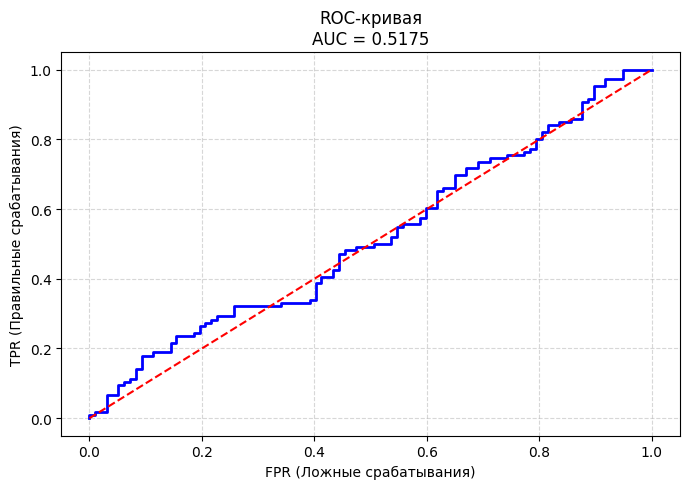

In [127]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
y_pred_proba = best_logreg.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5)
plt.xlabel('FPR (Ложные срабатывания)')
plt.ylabel('TPR (Правильные срабатывания)')
plt.title(f'ROC-кривая\nAUC = {roc_auc:.4f}')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **Метод Опорных векторов**

In [128]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(metrics.classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.56      0.67      0.61        97
           1       0.63      0.51      0.56       106

    accuracy                           0.59       203
   macro avg       0.59      0.59      0.58       203
weighted avg       0.59      0.59      0.58       203



In [129]:
def optuna_svm(trial):
    C = trial.suggest_float('C', 0.01, 2, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    shrinking = trial.suggest_categorical('shrinking', [True, False])
    max_iter = trial.suggest_int('max_iter', 500, 3000)
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    if kernel in ['rbf', 'poly', 'sigmoid']:
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto', 0.001, 0.01, 0.1, 1])
    else:
        gamma = 'scale' 
    if kernel == 'poly':
        degree = trial.suggest_int('degree', 2, 5)
        coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    else:
        degree = 3  
        coef0 = 0.0
    if kernel == 'sigmoid':
        coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    model = SVC(
        C=C, kernel=kernel, gamma=gamma, degree=degree, coef0=coef0, max_iter=max_iter, shrinking=shrinking, probability=True,
        class_weight=class_weight, random_state=42)

    f1_macro_scorer = make_scorer(f1_score, average='macro')
    
    scores = cross_val_score(
        model, 
        X=X_train, 
        y=y_train, 
        cv=kf, 
        scoring=f1_macro_scorer, 
        n_jobs=-1
    )
    
    score = np.mean(scores)
    return score
study_SVC = optuna.create_study(study_name='SVC', direction='maximize')
study_SVC.optimize(optuna_svm, n_trials=250, show_progress_bar=True)

[I 2025-12-07 18:20:18,150] A new study created in memory with name: SVC


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2025-12-07 18:20:18,802] Trial 0 finished with value: 0.46479402190370733 and parameters: {'C': 0.028979207711095557, 'kernel': 'poly', 'class_weight': 'balanced', 'shrinking': True, 'max_iter': 1857, 'tol': 0.0006899404873556805, 'gamma': 0.001, 'degree': 5, 'coef0': 0.7198094290365519}. Best is trial 0 with value: 0.46479402190370733.
[I 2025-12-07 18:20:19,350] Trial 1 finished with value: 0.3372359870090371 and parameters: {'C': 0.017578279790111638, 'kernel': 'sigmoid', 'class_weight': 'balanced', 'shrinking': False, 'max_iter': 1858, 'tol': 0.0003957321463590959, 'gamma': 0.01, 'coef0': 0.7675425757861513}. Best is trial 0 with value: 0.46479402190370733.
[I 2025-12-07 18:20:20,088] Trial 2 finished with value: 0.3313412928898502 and parameters: {'C': 0.12891361686986857, 'kernel': 'sigmoid', 'class_weight': 'balanced', 'shrinking': False, 'max_iter': 906, 'tol': 1.0849786585088299e-05, 'gamma': 'scale', 'coef0': 0.6591368751471524}. Best is trial 0 with value: 0.4647940219037

In [130]:
best_params_SVC = study_SVC.best_params
SVC_best = SVC(**best_params_SVC)
SVC_best.fit(X_train, y_train)
y_pred_best_SVC = SVC_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_best_SVC))

              precision    recall  f1-score   support

           0       0.45      0.68      0.54        97
           1       0.46      0.25      0.32       106

    accuracy                           0.45       203
   macro avg       0.45      0.46      0.43       203
weighted avg       0.45      0.45      0.43       203



ROC-AUC: 0.5962


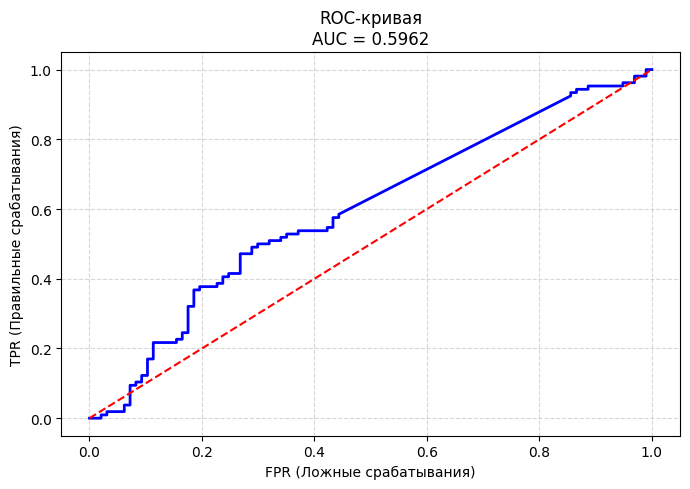

In [131]:
svm_best = SVC(probability=True)
svm_best.fit(X_train, y_train)

y_pred_proba = svm_best.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5)
plt.xlabel('FPR (Ложные срабатывания)')
plt.ylabel('TPR (Правильные срабатывания)')
plt.title(f'ROC-кривая\nAUC = {roc_auc:.4f}')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Деревья решений


## Основные параметры DecisionTreeClassifier:

- **`criterion`** — критерий информативности разбиения:
  - `'gini'` — критерий Джини (по умолчанию)
  - `'entropy'` — энтропия Шеннона

- **`max_depth`** — максимальная глубина дерева (по умолчанию — `None`, глубина дерева не ограничена)

- **`max_features`** — максимальное число признаков для поиска лучшего разбиения:
  - `None` — используются все признаки (по умолчанию)
  - `'sqrt'` — используется √n признаков
  - `'log2'` — используется log₂(n) признаков
  - число — используется указанное количество признаков

- **`min_samples_leaf`** — минимальное число объектов в листе (по умолчанию — 1)
  - *Интерпретация*: если параметр равен 5, дерево будет создавать только те правила, которые верны минимум для 5 объектов

- **`min_samples_split`** — минимальное число объектов для разделения узла (по умолчанию — 2)

- **`min_impurity_decrease`** — минимальное уменьшение неопределенности для разделения узла

- **`random_state`** — число, отвечающее за генерацию случайных чисел (для воспроизводимости результатов)

## Дополнительные параметры:

- **`splitter`** — стратегия выбора разделения в каждом узле:
  - `'best'` — лучшее разделение (по умолчанию)
  - `'random'` — случайное разделение

- **`max_leaf_nodes`** — максимальное количество листьев в дереве

- **`min_weight_fraction_leaf`** — минимальная взвешенная доля от общей суммы весов

In [132]:
# Базовая модель
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print(metrics.classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.46      0.45      0.46        97
           1       0.50      0.51      0.51       106

    accuracy                           0.48       203
   macro avg       0.48      0.48      0.48       203
weighted avg       0.48      0.48      0.48       203



Используем Optuna для подбора параметров

In [133]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

def optuna_rf(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    splitter = trial.suggest_categorical('splitter', ['best', 'random'])
    max_depth = trial.suggest_int('max_depth', 3, 50)
    
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30)
    min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = DecisionTreeClassifier(random_state=42, criterion=criterion, max_depth=max_depth, splitter=splitter,
                                        max_features=max_features, min_samples_split=min_samples_split,
                                        min_weight_fraction_leaf=min_weight_fraction_leaf,
                                        min_samples_leaf=min_samples_leaf)
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring=f1_macro_scorer, n_jobs=1)
    score = np.mean(scores)
    return score

study_tree = optuna.create_study(study_name='DecisionTreeClassifier', direction='maximize')
study_tree.optimize(optuna_rf, n_trials=250, show_progress_bar=True)
    

[I 2025-12-07 18:21:57,803] A new study created in memory with name: DecisionTreeClassifier


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2025-12-07 18:21:57,938] Trial 0 finished with value: 0.47348003177346054 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 46, 'min_samples_split': 16, 'min_samples_leaf': 27, 'min_weight_fraction_leaf': 0.4432240574434824, 'max_features': 'log2'}. Best is trial 0 with value: 0.47348003177346054.
[I 2025-12-07 18:21:58,289] Trial 1 finished with value: 0.5141245356273263 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 15, 'min_weight_fraction_leaf': 0.06472056710224833, 'max_features': None}. Best is trial 1 with value: 0.5141245356273263.
[I 2025-12-07 18:21:58,363] Trial 2 finished with value: 0.3372359870090371 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 41, 'min_samples_split': 30, 'min_samples_leaf': 6, 'min_weight_fraction_leaf': 0.3711034182004593, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.5141245356273263.
[I 2025-12-07 18:21:58,432] Tria

In [134]:
best_params_tree = study_tree.best_params
tree_best = DecisionTreeClassifier(**best_params_tree)
tree_best.fit(X_train, y_train)
y_pred_best_tree = tree_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_best_tree))

              precision    recall  f1-score   support

           0       0.51      0.51      0.51        97
           1       0.55      0.55      0.55       106

    accuracy                           0.53       203
   macro avg       0.53      0.53      0.53       203
weighted avg       0.53      0.53      0.53       203



ROC-AUC: 0.5201


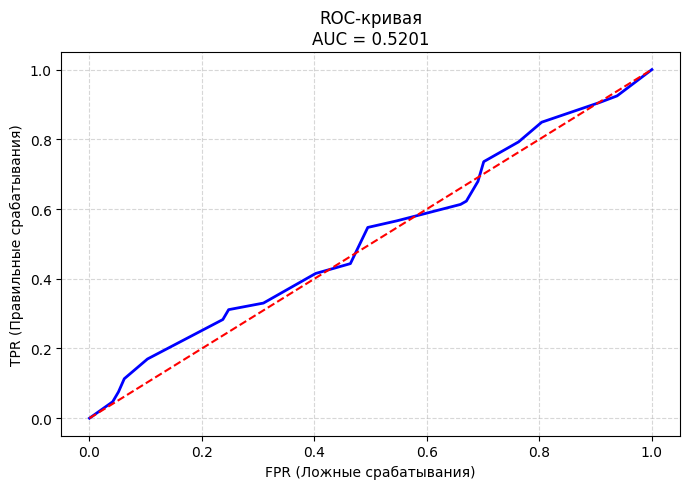

In [135]:
y_pred_proba = tree_best.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5)
plt.xlabel('FPR (Ложные срабатывания)')
plt.ylabel('TPR (Правильные срабатывания)')
plt.title(f'ROC-кривая\nAUC = {roc_auc:.4f}')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Случайный лес**

**Основные параметры RandomForestClassifier:**

* `n_estimators` — количество деревьев в лесу (число K из бэггинга; по умолчанию равно 100);
* `criterion` — критерий информативности разбиения для каждого из деревьев (`'gini'` — критерий Джини и `'entropy'` — энтропия Шеннона; по умолчанию — `'gini'`);
* `max_depth` — максимальная глубина одного дерева (по умолчанию — `None`, то есть глубина дерева не ограничена);
* `max_features` — максимальное число признаков, которые будут использоваться каждым из деревьев (число L из метода случайных подпространств; по умолчанию — `'sqrt'`; для обучения каждого из деревьев используется $\sqrt{m}$ признаков, где $m$ — число признаков в начальном наборе данных);
* `min_samples_leaf` — минимальное число объектов в листе (по умолчанию — 1);
* `random_state` — параметр, отвечающий за генерацию случайных чисел.


In [173]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
y_pred_random_forest = random_forest.predict(X_test)
print(metrics.classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.56      0.56      0.56        97
           1       0.60      0.60      0.60       106

    accuracy                           0.58       203
   macro avg       0.58      0.58      0.58       203
weighted avg       0.58      0.58      0.58       203



In [174]:
random_forest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

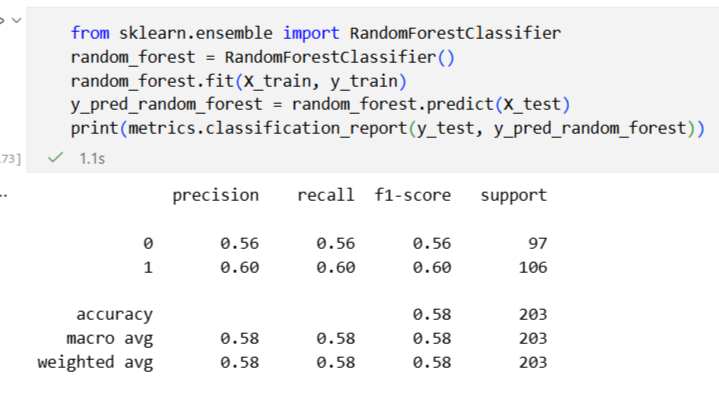

In [175]:
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 1, 5)
    
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30)
    min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    max_samples = trial.suggest_float('max_samples', 0.5, 1.0) if bootstrap else None
    
    model = RandomForestClassifier(
        random_state=42,
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        min_weight_fraction_leaf=min_weight_fraction_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        max_samples=max_samples,
        n_jobs=-1 
    )
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring=f1_macro_scorer, n_jobs=1)
    score = np.mean(scores)
    return score

study_rf = optuna.create_study(study_name='RandomForestClassifier', direction='maximize')
study_rf.optimize(objective_rf, n_trials=100, show_progress_bar=True)

[I 2025-12-07 19:26:11,262] A new study created in memory with name: RandomForestClassifier


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-07 19:26:13,607] Trial 0 finished with value: 0.4969762527572792 and parameters: {'n_estimators': 127, 'criterion': 'entropy', 'max_depth': 1, 'min_samples_split': 20, 'min_samples_leaf': 1, 'min_weight_fraction_leaf': 0.34550946190471093, 'max_features': 'log2', 'bootstrap': True, 'max_samples': 0.5380282407732158}. Best is trial 0 with value: 0.4969762527572792.
[I 2025-12-07 19:26:17,488] Trial 1 finished with value: 0.5371855420220693 and parameters: {'n_estimators': 348, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 12, 'min_weight_fraction_leaf': 0.04569595665573645, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.5371855420220693.
[I 2025-12-07 19:26:23,672] Trial 2 finished with value: 0.529859863158088 and parameters: {'n_estimators': 441, 'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 13, 'min_samples_leaf': 22, 'min_weight_fraction_leaf': 0.08702900391439189, 'max_features': 'sqrt', 'bo

In [176]:
best_params_random_forest= study_rf.best_params
print(best_params_random_forest)
random_forest_best = RandomForestClassifier(**best_params_random_forest)
random_forest_best.fit(X_train, y_train)
y_pred_random_forest_best = random_forest_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_random_forest_best))

{'n_estimators': 98, 'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 23, 'min_weight_fraction_leaf': 0.050283311641168, 'max_features': None, 'bootstrap': True, 'max_samples': 0.6915972081682917}
              precision    recall  f1-score   support

           0       0.58      0.39      0.47        97
           1       0.57      0.74      0.64       106

    accuracy                           0.57       203
   macro avg       0.57      0.56      0.55       203
weighted avg       0.57      0.57      0.56       203



ROC-AUC: 0.5625


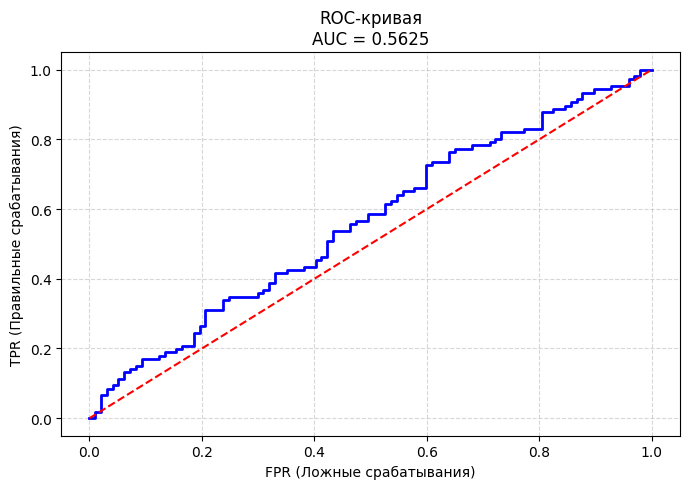

In [177]:
y_pred_proba = random_forest_best.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5)
plt.xlabel('FPR (Ложные срабатывания)')
plt.ylabel('TPR (Правильные срабатывания)')
plt.title(f'ROC-кривая\nAUC = {roc_auc:.4f}')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

KNN

In [140]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(metrics.classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.48      0.53      0.50        97
           1       0.53      0.48      0.50       106

    accuracy                           0.50       203
   macro avg       0.50      0.50      0.50       203
weighted avg       0.50      0.50      0.50       203



In [141]:
def objective_knn(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 30)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)
    
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        n_jobs=-1
    )
    
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train, y_train, cv=kf, 
                            scoring=f1_macro_scorer, n_jobs=1)
    
    return np.mean(scores)

study_rf = optuna.create_study(study_name='KNN', direction='maximize')
study_rf.optimize(objective_knn, n_trials=100, show_progress_bar=True)

[I 2025-12-07 18:28:43,451] A new study created in memory with name: KNN


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-07 18:28:43,701] Trial 0 finished with value: 0.5301754071138318 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.5301754071138318.
[I 2025-12-07 18:28:43,866] Trial 1 finished with value: 0.5362986454783532 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 1 with value: 0.5362986454783532.
[I 2025-12-07 18:28:44,016] Trial 2 finished with value: 0.535263751031764 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.5362986454783532.
[I 2025-12-07 18:28:44,163] Trial 3 finished with value: 0.5497290393877438 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'p': 1}. Best is trial 3 with value: 0.5497290393877438.
[I 2025-12-07 18:28:44,319] Trial 4 finished with value: 0.5378950004068729 and parameters: {'n_neighbors': 28, 'weights': 'distance', 'p': 2}. Best is trial 3 with value: 0.5497290393877438.
[I 2025-12-07 18:28:44,517] Trial 5 finishe

In [142]:
best_params_knn= study_rf.best_params
print(best_params_knn)
knn_best = KNeighborsClassifier(**best_params_knn)
knn_best.fit(X_train, y_train)
y_pred_knn_best = knn_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_knn_best))

{'n_neighbors': 8, 'weights': 'distance', 'p': 1}
              precision    recall  f1-score   support

           0       0.49      0.52      0.50        97
           1       0.53      0.50      0.51       106

    accuracy                           0.51       203
   macro avg       0.51      0.51      0.51       203
weighted avg       0.51      0.51      0.51       203



{'n_estimators': 233, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 23, 'min_samples_leaf': 25, 'min_weight_fraction_leaf': 0.006487912202141996, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.5129813025570336}
              precision    recall  f1-score   support

           0       0.58      0.42      0.49        97
           1       0.58      0.72      0.64       106

    accuracy                           0.58       203
   macro avg       0.58      0.57      0.56       203
weighted avg       0.58      0.58      0.57       203

# **XGBClassifier**

## Основные параметры:

- **`n_estimators`** — количество деревьев в ансамбле (по умолчанию равно 100)
- **`max_depth`** — максимальная глубина одного дерева (по умолчанию — 6)
- **`learning_rate`** — скорость обучения, шаг градиентного спуска (по умолчанию — 0.3)
- **`subsample`** — доля объектов, используемых для обучения каждого дерева (по умолчанию — 1.0)
- **`colsample_bytree`** — доля признаков, используемых для построения каждого дерева (по умолчанию — 1.0)
- **`colsample_bylevel`** — доля признаков, используемых на каждом уровне разделения дерева (по умолчанию — 1.0)
- **`colsample_bynode`** — доля признаков, используемых для каждого разделения узла дерева (по умолчанию — 1.0)
- **`min_child_weight`** — минимальная сумма весов объектов в листе (по умолчанию — 1)
- **`gamma`** — минимальное уменьшение функции потерь, необходимое для выполнения разделения узла (по умолчанию — 0)
- **`reg_alpha`** — коэффициент L1-регуляризации (LASSO; по умолчанию — 0)
- **`reg_lambda`** — коэффициент L2-регуляризации (Ridge; по умолчанию — 1)
- **`scale_pos_weight`** — коэффициент для балансировки весов классов в случае несбалансированных данных (по умолчанию — 1)
- **`random_state`** — параметр, отвечающий за генерацию случайных чисел

In [180]:
from xgboost import XGBClassifier
XGB = XGBClassifier(random_state=42)
XGB.fit(X_train, y_train)
y_pred_xgb = XGB.predict(X_test)
print(metrics.classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.52      0.47      0.50        97
           1       0.56      0.60      0.58       106

    accuracy                           0.54       203
   macro avg       0.54      0.54      0.54       203
weighted avg       0.54      0.54      0.54       203



In [144]:
def objective_xgb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 1.0)
    reg_lambda = trial.suggest_float('reg_lambda', 0.5, 2.0)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        min_child_weight=min_child_weight,
        random_state=42,
        n_jobs=2,  
        eval_metric='logloss'
    )
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train, y_train, scoring=f1_macro_scorer, cv=kf, n_jobs=1)
    score = np.mean(scores)
    
    return score

study_xgb = optuna.create_study(study_name='XGBClassifier', direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)


[I 2025-12-07 18:29:00,899] A new study created in memory with name: XGBClassifier


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-12-07 18:29:02,270] Trial 0 finished with value: 0.5466159253357719 and parameters: {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.012263299474400304, 'subsample': 0.9878816036645913, 'colsample_bytree': 0.6682735043906395, 'reg_alpha': 0.45273573872194395, 'reg_lambda': 1.6540570797215717, 'min_child_weight': 7}. Best is trial 0 with value: 0.5466159253357719.
[I 2025-12-07 18:29:03,277] Trial 1 finished with value: 0.5384402467194083 and parameters: {'n_estimators': 70, 'max_depth': 5, 'learning_rate': 0.13121274399376484, 'subsample': 0.9122688150420695, 'colsample_bytree': 0.9378347144688202, 'reg_alpha': 0.46881675954231217, 'reg_lambda': 1.1680697138564702, 'min_child_weight': 4}. Best is trial 0 with value: 0.5466159253357719.
[I 2025-12-07 18:29:05,180] Trial 2 finished with value: 0.5357153900125812 and parameters: {'n_estimators': 188, 'max_depth': 6, 'learning_rate': 0.16261120360513373, 'subsample': 0.9086798874356141, 'colsample_bytree': 0.721576550882885

In [145]:
best_params_xgb = study_xgb.best_params
print(best_params_xgb)
xgb_best = XGBClassifier(**best_params_xgb, random_state=42)
xgb_best.fit(X_train, y_train)
y_pred_xgb_best = xgb_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_xgb_best))

{'n_estimators': 256, 'max_depth': 4, 'learning_rate': 0.03284921615942426, 'subsample': 0.6788574432947295, 'colsample_bytree': 0.9184914226599531, 'reg_alpha': 0.8363521899054912, 'reg_lambda': 1.0735460123304625, 'min_child_weight': 4}
              precision    recall  f1-score   support

           0       0.57      0.52      0.54        97
           1       0.59      0.64      0.62       106

    accuracy                           0.58       203
   macro avg       0.58      0.58      0.58       203
weighted avg       0.58      0.58      0.58       203



ROC-AUC: 0.5983


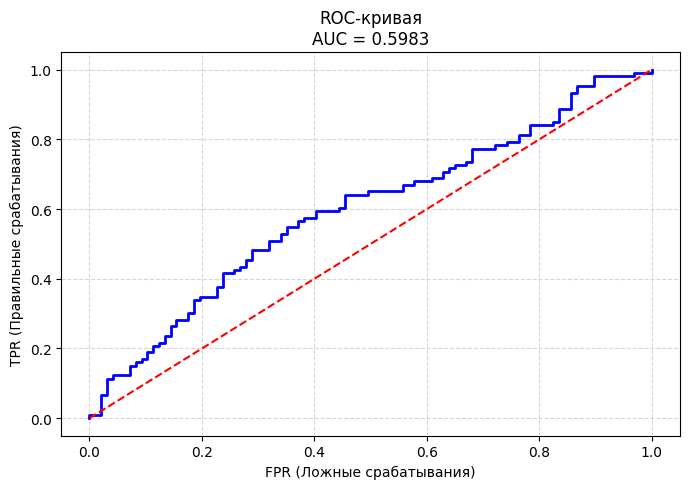

In [146]:
y_pred_proba = xgb_best.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5)
plt.xlabel('FPR (Ложные срабатывания)')
plt.ylabel('TPR (Правильные срабатывания)')
plt.title(f'ROC-кривая\nAUC = {roc_auc:.4f}')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [198]:
best_params_random_forest_ = {'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}
random_forest_best = RandomForestClassifier(**best_params_random_forest_)
random_forest_best.fit(X_train, y_train)
y_pred_random_forest_best_ = random_forest_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_random_forest_best_))

              precision    recall  f1-score   support

           0       0.55      0.56      0.55        97
           1       0.59      0.58      0.58       106

    accuracy                           0.57       203
   macro avg       0.57      0.57      0.57       203
weighted avg       0.57      0.57      0.57       203



In [158]:
profit_test = df_ml_after[df_ml_after['profit'] !=0]['profit']

<Axes: ylabel='profit'>

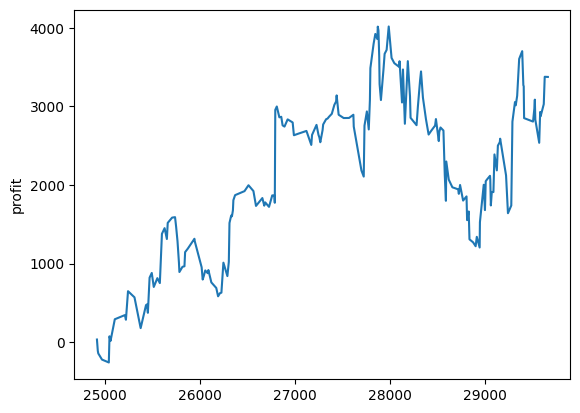

In [159]:
profit_test_cum = np.cumsum(profit_test)
sns.lineplot(profit_test_cum)

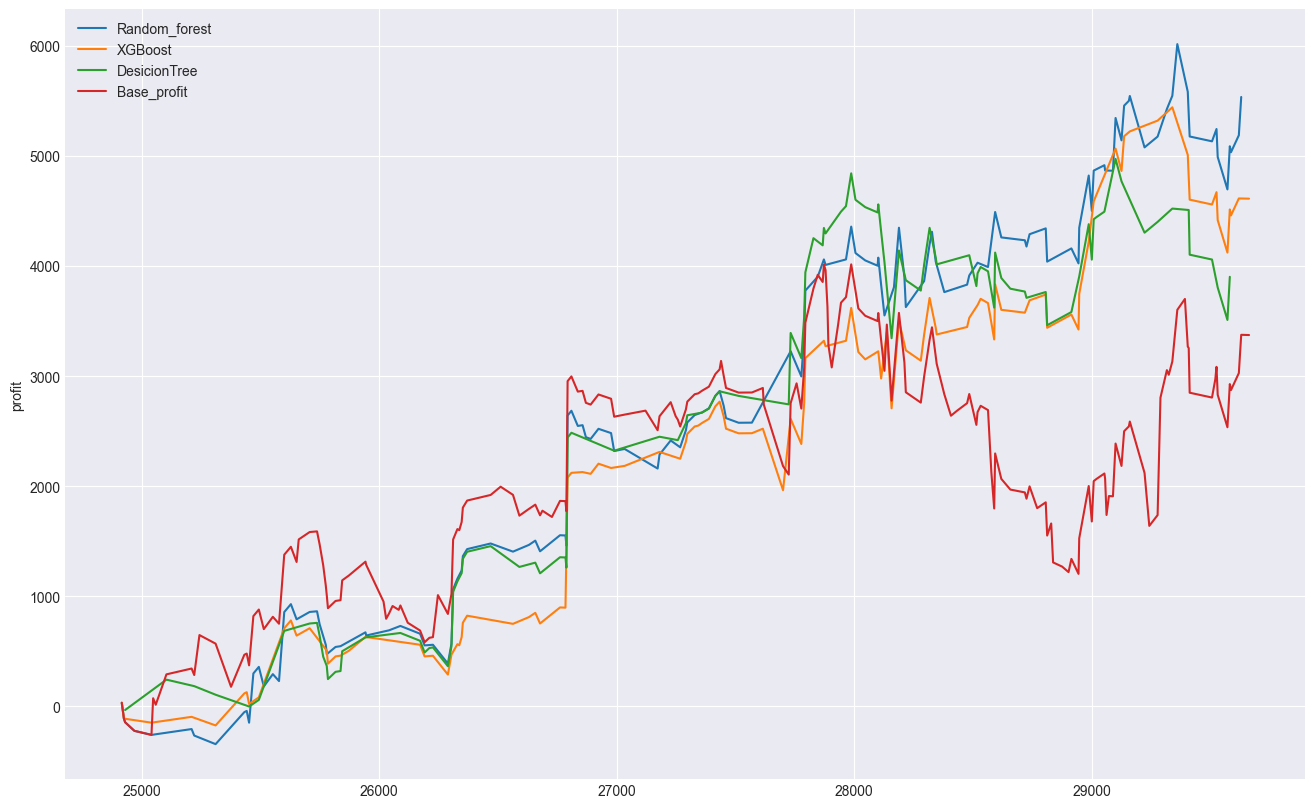

In [202]:
# Logreg
y_pred_logreg_plus = profit_test[y_pred_logreg > 0]
y_pred_logreg_best_cumsum = np.cumsum(y_pred_logreg_plus)
#XGboost
y_pred_xgb_best_plus = profit_test[y_pred_xgb_best > 0]
y_pred_xgb_best_cumsum = np.cumsum(y_pred_xgb_best_plus)
#SVC
y_pred_svm_best_plus = profit_test[y_pred_svm >0]
y_pred_svm_best_cumsum = np.cumsum(y_pred_svm_best_plus)
#Decision_Tree
y_pred_best_tree_plus = profit_test[y_pred_best_tree>0]
y_pred_best_tree_cumsum = np.cumsum(y_pred_best_tree_plus)
#Random_forest
y_pred_random_forest_best_plus = profit_test[y_pred_random_forest_best > 0]
y_pred_random_forest_best_cumsum = np.cumsum(y_pred_random_forest_best_plus)
# Доходность всех паттернов
plt.figure(figsize=(16, 10))
sns.lineplot(y_pred_random_forest_best_cumsum, label='Random_forest')
sns.lineplot(y_pred_xgb_best_cumsum, label='XGBoost')
sns.lineplot(y_pred_best_tree_cumsum, label='DesicionTree')
sns.lineplot(profit_test_cum, label='Base_profit');

## Финальный поиск гиперпараметров лучших моделей и сравнение с базовой версией

## 1. Случайный лес

In [203]:
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 1, 5)
    
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30)
    min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    max_samples = trial.suggest_float('max_samples', 0.5, 1.0) if bootstrap else None
    
    model = RandomForestClassifier(
        random_state=42,
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        min_weight_fraction_leaf=min_weight_fraction_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        max_samples=max_samples,
        n_jobs=-1 
    )
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring=f1_macro_scorer, n_jobs=1)
    score = np.mean(scores)
    return score

study_rf = optuna.create_study(study_name='RandomForestClassifier', direction='maximize')
study_rf.optimize(objective_rf, n_trials=200, show_progress_bar=True)

[I 2025-12-07 20:09:20,678] A new study created in memory with name: RandomForestClassifier


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-12-07 20:09:21,258] Trial 0 finished with value: 0.4763048798633693 and parameters: {'n_estimators': 51, 'criterion': 'gini', 'max_depth': 1, 'min_samples_split': 4, 'min_samples_leaf': 21, 'min_weight_fraction_leaf': 0.11066011127531955, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.4763048798633693.
[I 2025-12-07 20:09:23,469] Trial 1 finished with value: 0.5489460438168556 and parameters: {'n_estimators': 157, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 9, 'min_samples_leaf': 20, 'min_weight_fraction_leaf': 0.006674075460791407, 'max_features': None, 'bootstrap': True, 'max_samples': 0.9749318123900227}. Best is trial 1 with value: 0.5489460438168556.
[I 2025-12-07 20:09:24,755] Trial 2 finished with value: 0.5261494798156214 and parameters: {'n_estimators': 179, 'criterion': 'entropy', 'max_depth': 1, 'min_samples_split': 6, 'min_samples_leaf': 9, 'min_weight_fraction_leaf': 0.16956775788280432, 'max_features': None, 'bootstrap': 

In [205]:
best_params_final_random_forest= study_rf.best_params
print(best_params_final_random_forest)
random_forest_final = RandomForestClassifier(**best_params_final_random_forest)
random_forest_final.fit(X_train, y_train)
y_pred_random_forest_final = random_forest_final.predict(X_test)
print(metrics.classification_report(y_test, y_pred_random_forest_final))

{'n_estimators': 304, 'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 25, 'min_weight_fraction_leaf': 0.03370804924804307, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.5623209959631084}
              precision    recall  f1-score   support

           0       0.57      0.53      0.55        97
           1       0.59      0.63      0.61       106

    accuracy                           0.58       203
   macro avg       0.58      0.58      0.58       203
weighted avg       0.58      0.58      0.58       203



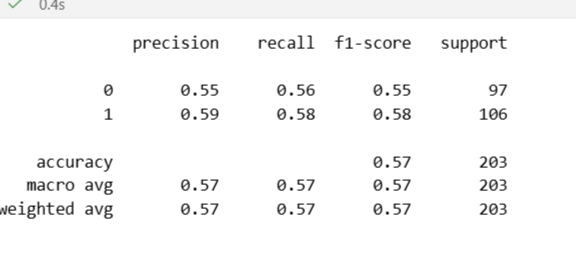

In [207]:
final_params_random_forest = random_forest_final.get_params()
print(final_params_random_forest)

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': 0.5623209959631084, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 25, 'min_samples_split': 9, 'min_weight_fraction_leaf': 0.03370804924804307, 'monotonic_cst': None, 'n_estimators': 304, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


Случайный лес лучшие параметры:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': 0.5623209959631084, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 25, 'min_samples_split': 9, 'min_weight_fraction_leaf': 0.03370804924804307, 'monotonic_cst': None, 'n_estimators': 304, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}

# 2. XGBoost

In [221]:
def objective_xgb(trial):
    # Существующие параметры
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 1.0)
    reg_lambda = trial.suggest_float('reg_lambda', 0.5, 2.0)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    
    gamma = trial.suggest_float('gamma', 0, 0.5, step=0.05)
    max_delta_step = trial.suggest_int('max_delta_step', 0, 10)
    colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.6, 1.0)
    colsample_bynode = trial.suggest_float('colsample_bynode', 0.6, 1.0)
    max_leaves = trial.suggest_int('max_leaves', 0, 64)  # 0 = нет ограничения
    tree_method = trial.suggest_categorical('tree_method', ['hist', 'approx', 'auto'])
    grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        min_child_weight=min_child_weight,
        random_state=42,
        n_jobs=-1,  
        eval_metric='logloss'
    )
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train, y_train, scoring=f1_macro_scorer, cv=kf, n_jobs=1)
    score = np.mean(scores)
    
    return score

study_xgb = optuna.create_study(study_name='XGBClassifier', direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=500, show_progress_bar=True)

[I 2025-12-07 20:47:58,343] A new study created in memory with name: XGBClassifier


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2025-12-07 20:47:58,974] Trial 0 finished with value: 0.5453579539542064 and parameters: {'n_estimators': 119, 'max_depth': 4, 'learning_rate': 0.09355272050449931, 'subsample': 0.7164458969060561, 'colsample_bytree': 0.857623883377129, 'reg_alpha': 0.561637853350427, 'reg_lambda': 0.982565188603018, 'min_child_weight': 6, 'gamma': 0.30000000000000004, 'max_delta_step': 10, 'colsample_bylevel': 0.7510345092495949, 'colsample_bynode': 0.892453478215101, 'max_leaves': 23, 'tree_method': 'auto', 'grow_policy': 'lossguide'}. Best is trial 0 with value: 0.5453579539542064.
[I 2025-12-07 20:47:59,889] Trial 1 finished with value: 0.5415737907441429 and parameters: {'n_estimators': 157, 'max_depth': 9, 'learning_rate': 0.1944834808829217, 'subsample': 0.6612072023167153, 'colsample_bytree': 0.9274594169257502, 'reg_alpha': 0.3090218069337284, 'reg_lambda': 1.2918444183997335, 'min_child_weight': 8, 'gamma': 0.05, 'max_delta_step': 6, 'colsample_bylevel': 0.7632839065129601, 'colsample_byno

In [222]:
final_params_xgb = study_xgb.best_params
print(final_params_xgb)
xgb_final = XGBClassifier(**best_params_xgb, random_state=42)
xgb_final.fit(X_train, y_train)
y_pred_xgb_final = xgb_final.predict(X_test)
print(metrics.classification_report(y_test, y_pred_xgb_final))

{'n_estimators': 176, 'max_depth': 4, 'learning_rate': 0.018852808679886018, 'subsample': 0.7554886892675864, 'colsample_bytree': 0.9555305335844859, 'reg_alpha': 0.2906071402048399, 'reg_lambda': 1.200311688874489, 'min_child_weight': 2, 'gamma': 0.15000000000000002, 'max_delta_step': 7, 'colsample_bylevel': 0.8273873842723534, 'colsample_bynode': 0.8268665360861707, 'max_leaves': 44, 'tree_method': 'approx', 'grow_policy': 'depthwise'}
              precision    recall  f1-score   support

           0       0.57      0.52      0.54        97
           1       0.59      0.64      0.62       106

    accuracy                           0.58       203
   macro avg       0.58      0.58      0.58       203
weighted avg       0.58      0.58      0.58       203



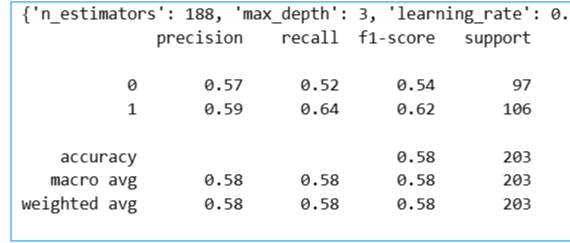

In [223]:
final_params_xgboost = xgb_final.get_params()
print(final_params_xgboost)

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9184914226599531, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.03284921615942426, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 4, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 256, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.8363521899054912, 'reg_lambda': 1.0735460123304625, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.6788574432947295, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


Лучшие параметры для XGboost:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9184914226599531, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.03284921615942426, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 4, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 256, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.8363521899054912, 'reg_lambda': 1.0735460123304625, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.6788574432947295, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

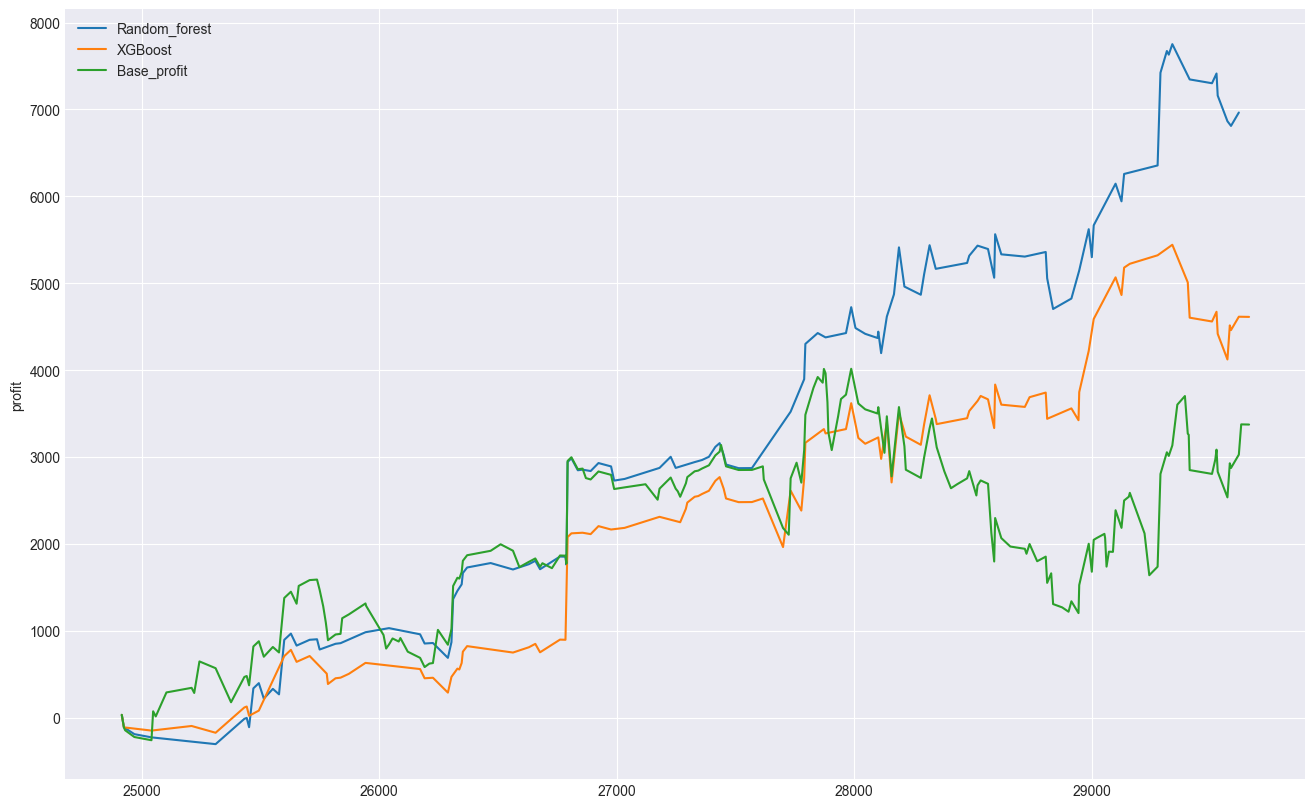

In [240]:
#XGboost
y_pred_xgb_best_plus = profit_test[y_pred_xgb_final > 0]
y_pred_xgb_best_cumsum = np.cumsum(y_pred_xgb_best_plus)
#Random_forest
y_pred_random_forest_best_plus = profit_test[y_pred_random_forest_final > 0]
y_pred_random_forest_best_cumsum = np.cumsum(y_pred_random_forest_best_plus)
profit_test_cum = np.cumsum(profit_test)
# Доходность всех паттернов
plt.figure(figsize=(16, 10))
sns.lineplot(y_pred_random_forest_best_cumsum, label='Random_forest')
sns.lineplot(y_pred_xgb_best_cumsum, label='XGBoost')
sns.lineplot(profit_test_cum, label='Base_profit');

In [233]:
# Базовая стратегия
base_average_profit = np.mean(profit_test[profit_test > 0])
base_average_loss = np.mean(profit_test[profit_test < 0])
base_count_profit = len(profit_test[profit_test > 0])
base_count_loss = len(profit_test[profit_test < 0])
print('Base')
print(base_average_profit)
print(base_average_loss)
print(base_count_profit)
# Random Forest
RF_average_profit = np.mean(y_pred_random_forest_best_plus[y_pred_random_forest_best_plus > 0])
RF_average_loss = np.mean(y_pred_random_forest_best_plus[y_pred_random_forest_best_plus < 0])
print('Random Forest')
print(RF_average_profit)
print(RF_average_loss)
# XGboost
XGboost_average_profit = np.mean(y_pred_xgb_best_plus[y_pred_xgb_best_plus > 0])
XGboost_average_loss = np.mean(y_pred_xgb_best_plus[y_pred_xgb_best_plus < 0])
print('XGboost')
print(XGboost_average_profit)
print(XGboost_average_loss)

Base
185.19811320754718
-167.5979381443299
106
Random Forest
203.91044776119404
-145.58695652173913
XGboost
177.48529411764707
-158.63829787234042


In [241]:
# Базовая стратегия

base_profitable = profit_test[profit_test > 0]
base_loss = profit_test[profit_test < 0]
base_average_profit = np.mean(base_profitable)
base_average_loss = np.mean(base_loss)
base_count_profit = len(base_profitable)
base_count_loss = len(base_loss)
base_total_trades = len(profit_test)
base_winrate = base_count_profit / base_total_trades
base_profit_factor = base_profitable.sum() / abs(base_loss.sum())
base_cumsum = np.cumsum(profit_test)
# R^2
X_base = np.array(list(range(len(base_cumsum)))).reshape(-1, 1)
lin_base = LinearRegression()
lin_base.fit(X_base, base_cumsum)
y_pred_base = lin_base.predict(X_base)
r2_base = r2_score(base_cumsum, y_pred_base)

print('Base')
print('Средняя прибыль:', base_average_profit)
print('Средний убыток:', base_average_loss)
print('Кол-во прибыльных:', base_count_profit)
print('Win Rate:', base_winrate)
print('Профит фактор:', base_profit_factor)
print('R²:', r2_base)
print()

# Random Forest
RF_profitable = y_pred_random_forest_best_plus[y_pred_random_forest_best_plus > 0]
RF_loss = y_pred_random_forest_best_plus[y_pred_random_forest_best_plus < 0]
RF_average_profit = np.mean(RF_profitable)
RF_average_loss = np.mean(RF_loss)
RF_count_profit = len(RF_profitable)
RF_count_loss = len(RF_loss)
RF_total_trades = len(y_pred_random_forest_best_plus)
RF_winrate = RF_count_profit / RF_total_trades
RF_profit_factor = RF_profitable.sum() / abs(RF_loss.sum())
RF_cumsum = np.cumsum(y_pred_random_forest_best_plus)
# R^2
X_RF = np.array(list(range(len(RF_cumsum)))).reshape(-1, 1)
lin_base = LinearRegression()
lin_base.fit(X_RF, RF_cumsum)
y_pred_RF = lin_base.predict(X_RF)
r2_RF = r2_score(RF_cumsum, y_pred_RF)

print('Random Forest')
print('Средняя прибыль:', RF_average_profit)
print('Средний убыток:', RF_average_loss)
print('Кол-во прибыльных:', RF_count_profit)
print('Win Rate:', RF_winrate)
print('Профит фактор:', RF_profit_factor)
print('R²:', r2_RF)
print()

# XGBoost
XGB_profitable = y_pred_xgb_best_plus[y_pred_xgb_best_plus > 0]
XGB_loss = y_pred_xgb_best_plus[y_pred_xgb_best_plus < 0]
XGB_average_profit = np.mean(XGB_profitable)
XGB_average_loss = np.mean(XGB_loss)
XGB_count_profit = len(XGB_profitable)
XGB_count_loss = len(XGB_loss)
XGB_total_trades = len(y_pred_xgb_best_plus)
XGB_winrate = XGB_count_profit / XGB_total_trades
XGB_profit_factor = XGB_profitable.sum() / abs(XGB_loss.sum())
XGB_cumsum = np.cumsum(y_pred_xgb_best_plus)
# R^2
X_XGB = np.array(list(range(len(XGB_cumsum)))).reshape(-1, 1)
lin_base = LinearRegression()
lin_base.fit(X_XGB, XGB_cumsum)
y_pred_XGB = lin_base.predict(X_XGB)
r2_XGB = r2_score(XGB_cumsum, y_pred_XGB)

print('XGBoost')
print('Средняя прибыль:', XGB_average_profit)
print('Средний убыток:', XGB_average_loss)
print('Кол-во прибыльных:', XGB_count_profit)
print('Win Rate:', XGB_winrate)
print('Профит фактор:', XGB_profit_factor)
print('R²:', r2_XGB)

Base
Средняя прибыль: 185.19811320754718
Средний убыток: -167.5979381443299
Кол-во прибыльных: 106
Win Rate: 0.5221674876847291
Профит фактор: 1.207541366795842
R²: 0.3994925260593454

Random Forest
Средняя прибыль: 203.91044776119404
Средний убыток: -145.58695652173913
Кол-во прибыльных: 67
Win Rate: 0.5929203539823009
Профит фактор: 2.0400179184709573
R²: 0.9681957317152461

XGBoost
Средняя прибыль: 177.48529411764707
Средний убыток: -158.63829787234042
Кол-во прибыльных: 68
Win Rate: 0.591304347826087
Профит фактор: 1.6186963519313304
R²: 0.9325638137893892


In [245]:
import pandas as pd

# Создаем DataFrame
results_df = pd.DataFrame({
    'Модель': ['Base', 'Random Forest', 'XGBoost'],
    'Средняя_прибыль': [base_average_profit, RF_average_profit, XGB_average_profit],
    'Средний_убыток': [base_average_loss, RF_average_loss, XGB_average_loss],
    'Прибыльные_сделки': [base_count_profit, RF_count_profit, XGB_count_profit],
    'Убыточные_сделки': [base_count_loss, RF_count_loss, XGB_count_loss],
    'Всего_сделок': [base_total_trades, RF_total_trades, XGB_total_trades],
    'Win_Rate': [base_winrate, RF_winrate, XGB_winrate],
    'Профит_фактор': [base_profit_factor, RF_profit_factor, XGB_profit_factor],
    'R2': [r2_base, r2_RF, r2_XGB]
})

# Округляем значения для красивого отображения
display_df = results_df.copy()
display_df['Средняя_прибыль'] = display_df['Средняя_прибыль'].round(4)
display_df['Средний_убыток'] = display_df['Средний_убыток'].round(4)
display_df['Win_Rate'] = display_df['Win_Rate'].round(4)
display_df['Профит_фактор'] = display_df['Профит_фактор'].round(4)
display_df['R2'] = display_df['R2'].round(4)

# Выводим таблицу
display_df

,Модель,Средняя_прибыль,Средний_убыток,Прибыльные_сделки,Убыточные_сделки,Всего_сделок,Win_Rate,Профит_фактор,R2
0,Base,185.1981,-167.5979,106,97,203,0.5222,1.2075,0.3995
1,Random Forest,203.9104,-145.5870,67,46,113,0.5929,2.0400,0.9682
2,XGBoost,177.4853,-158.6383,68,47,115,0.5913,1.6187,0.9326


Без удаления признаков

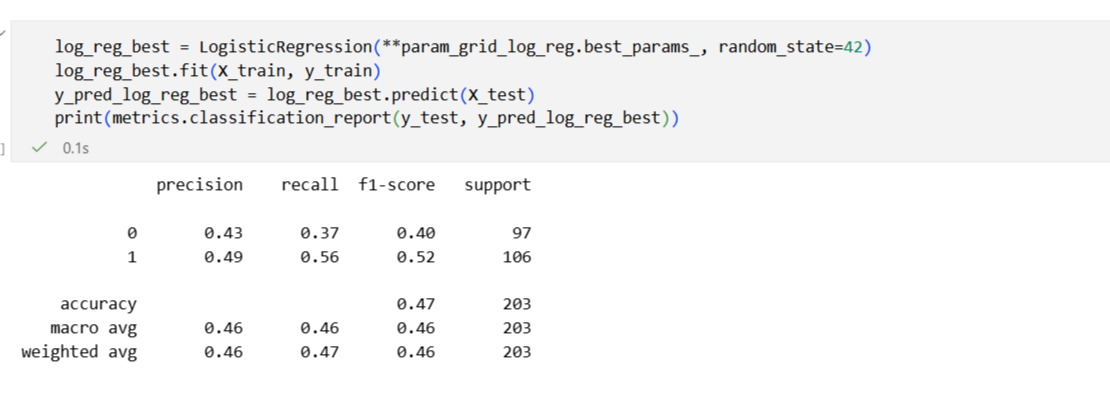

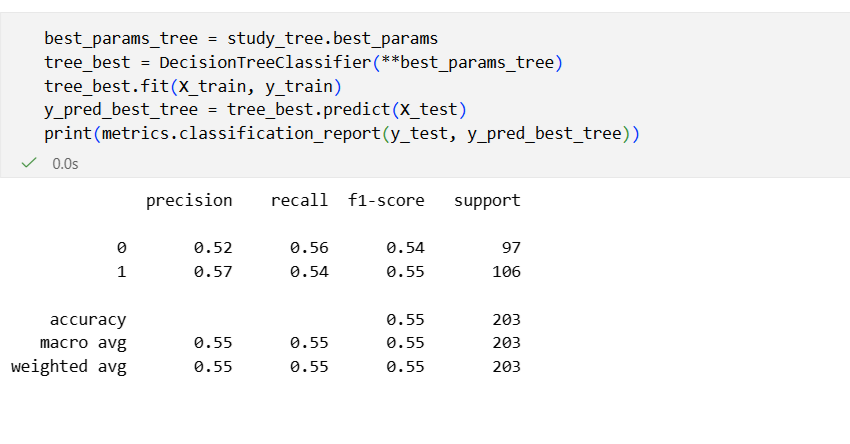

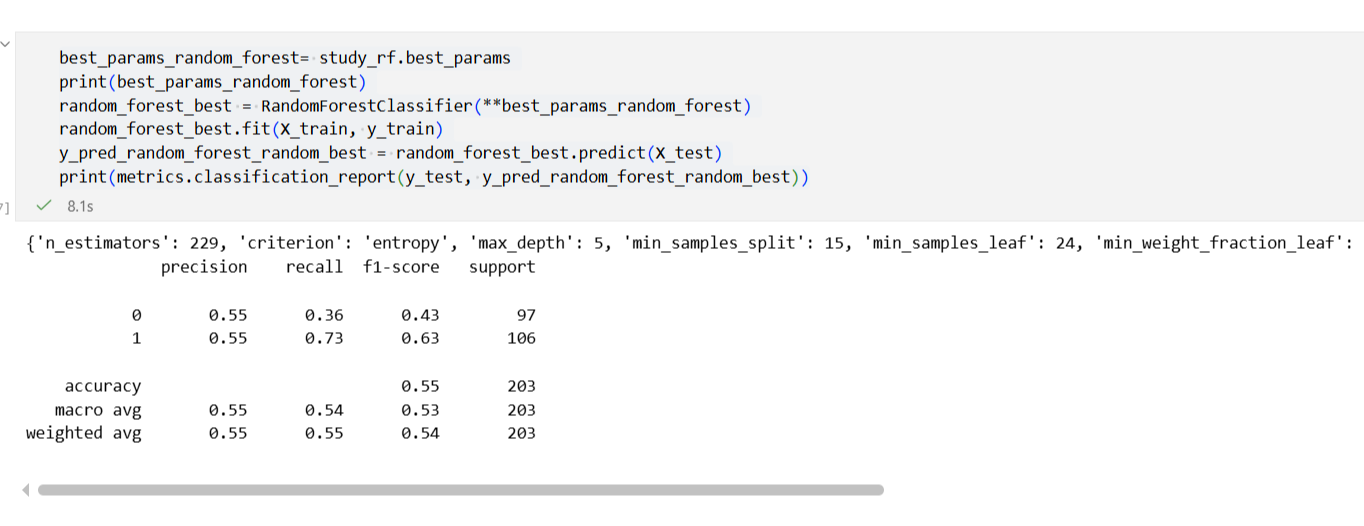

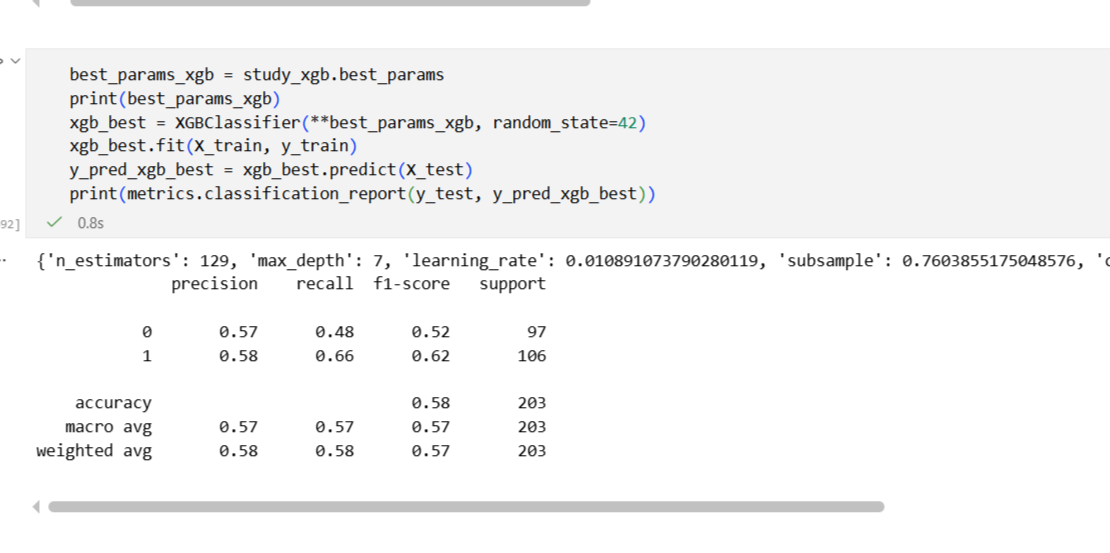

**С удалением**

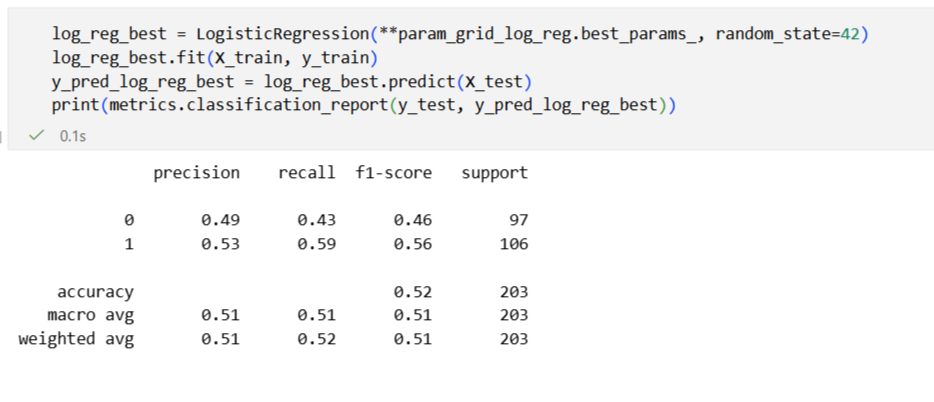

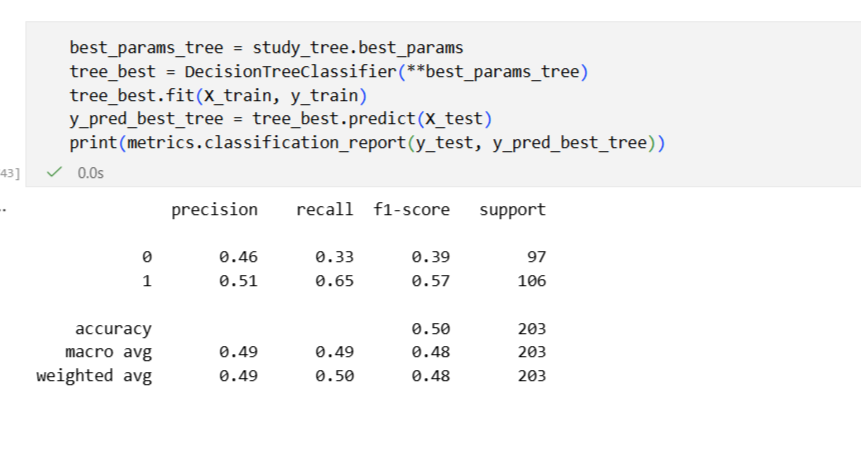

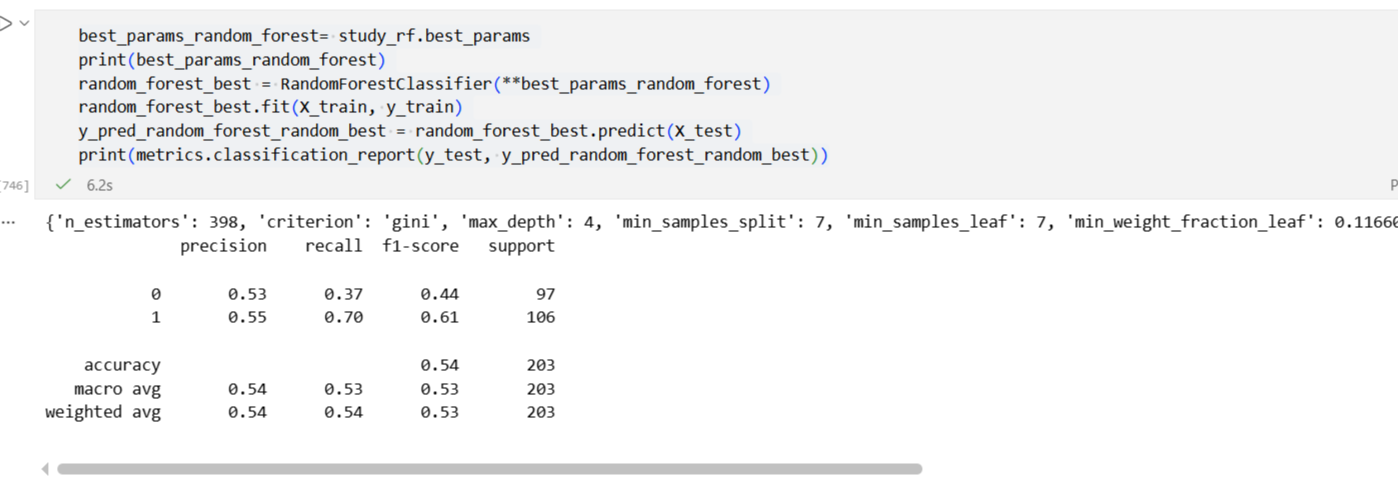

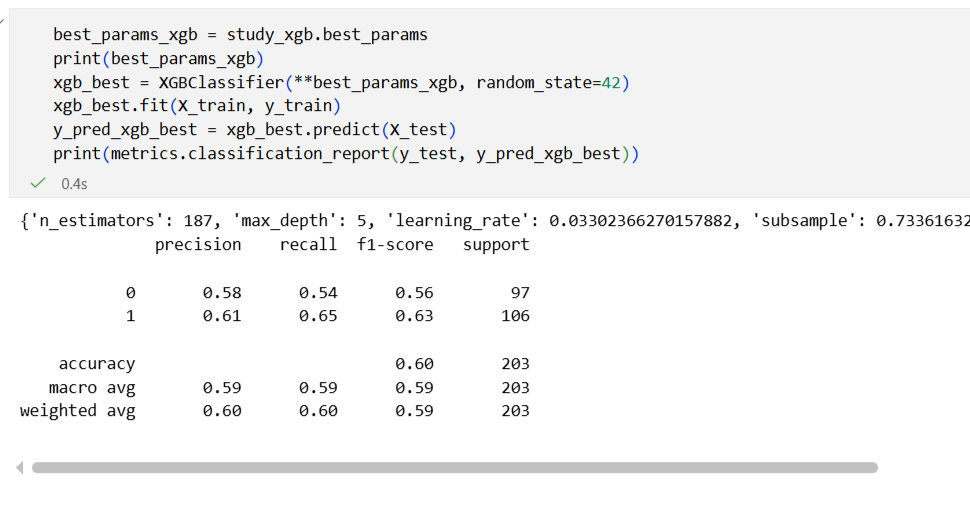